In [22]:
#Run B matrix circuit on various input states
using QuantumOptics
using Plots


b_spin = SpinBasis(1//2)

const sx = sigmax(b_spin)
const sy = sigmay(b_spin)
const sz = sigmaz(b_spin)
const sp = (sx + 1im*sy)/2
const sm = (sx - 1im*sy)/2

const up = spinup(b_spin)
const down = spindown(b_spin)
const I_s = identityoperator(b_spin)


function Rn_id(psi, theta, sn, id)
    if id == 0
        return exp(-1im * theta/2 * tensor(sn, I_s))*psi
    elseif id == 1
        return exp(-1im * theta/2 * tensor(I_s, sn))*psi
    end
end

function Rxx(psi, theta)
    psi = exp(-1im * theta/2 * tensor(sx, sx))*psi
    return psi
end

function B_matrix(psi)
    psi = Rn_id(psi, -pi/2, sz, 1)
    psi = Rxx(psi, pi/4)
    psi = Rn_id(psi, +pi/2, sz, 1)
    psi = Rn_id(psi, -pi/2, sz, 0)
    psi = Rxx(psi, -pi/4)
    return psi
end

function B_matrix_dm(rho)
    rho = exp(-1im * (-pi/2)/2 * tensor(I_s, sz))*rho*exp(1im * (-pi/2)/2 * tensor(I_s, sz))
    rho = exp(-1im * (pi/4)/2 * tensor(sx, sx))*rho*exp(1im * (pi/4)/2 * tensor(sx, sx))
    rho = exp(-1im * (pi/2)/2 * tensor(I_s, sz))*rho*exp(1im * (pi/2)/2 * tensor(I_s, sz))
    rho = exp(-1im * (-pi/2)/2 * tensor(sz, I_s))*rho*exp(1im * (-pi/2)/2 * tensor(sz, I_s))
    rho = exp(-1im * (-pi/4)/2 * tensor(sx, sx))*rho*exp(1im * (-pi/4)/2 * tensor(sx, sx))
    return rho
end


const up2 = tensor(up, up)
const up_down = tensor(up, down)
const down_up = tensor(down, up)
const down2 = tensor(down, down)

function measure2(psi)
    p_uu = abs2(dagger(up2)* psi)
    p_dd = abs2(dagger(down2)* psi)
    p_ud = abs2(dagger(up_down)* psi)
    p_du = abs2(dagger(down_up)* psi)
    # assert total prob is 1
    total_prob = p_uu + p_dd + p_ud + p_du
    @assert round(total_prob, digits=5) == 1.0 "Total probability is not 1, got $total_prob"
    return p_uu, p_dd, p_ud, p_du
end

function measure2_dm(rho)
    p_uu = real(expect(projector(up2), rho))
    p_dd = real(expect(projector(down2), rho))
    p_ud = real(expect(projector(up_down), rho))
    p_du = real(expect(projector(down_up), rho))
    # assert total prob is 1
    total_prob = p_uu + p_dd + p_ud + p_du
    @assert round(total_prob, digits=5) == 1.0 "Total probability is not 1, got $total_prob"
    return p_uu, p_dd, p_ud, p_du
end

function measure1(psi, id)
    if id == 0
        print(psi)
        # trace qubit 1 out
        rho = ptrace(psi, [1])
    elseif id == 1
        # trace qubit 0 out
        rho = ptrace(psi, [0])
    end
    p_up = real(expect(projector(up), rho))
    p_down = real(expect(projector(down), rho))
    return p_up, p_down
end

function depol_chan(psi, p)
    rho_0 = ptrace(projector(psi), [2])
    rho_1 = ptrace(projector(psi), [1])
    rho_d0 = (1-p)*rho_0 + p*I_s/2
    rho_d1 = (1-p)*rho_1 + p*I_s/2
    rho = tensor(rho_d0, rho_d1)

    return rho
end

depol_chan (generic function with 1 method)

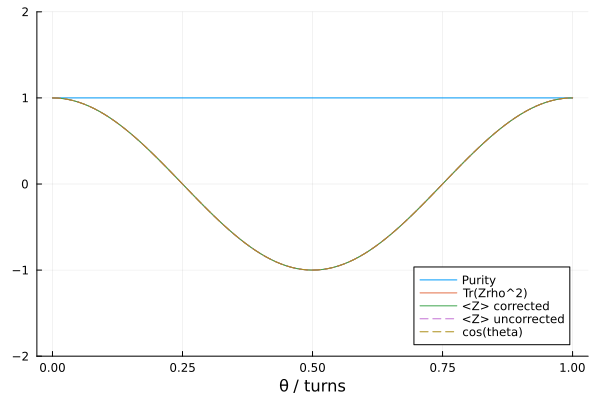

In [18]:
psi_0 = tensor(up, up)
turns_list = collect(0:0.01:1)
#theta_list = collect(0:1e-2:1e-1)
purity_list = []
corrected_list = []
uncorrected_list = []
tr_rho_2_Z_list = []

for turns in turns_list
    # Create initial state
    psi = Rn_id(psi_0, turns*2pi, sx, 0)
    psi = Rn_id(psi, turns*2pi, sx, 1)

    # Apply B matrix circuit
    psi_derang = B_matrix(psi)

    # Measure the state in the computational basis
    p_uu, p_dd, p_ud, p_du = measure2(psi_derang)

    # Post process
    M0 = p_uu + p_ud - p_du - p_dd
    M1 = p_uu + p_du - p_ud - p_dd
    M01 = p_uu+ p_dd - p_ud - p_du
    purity = 1/2 * ( 1 + M0 - M1 + M01)
    tr_rho_2_Z = 1/2 * (M0 + M1)
    push!(purity_list, purity)
    push!(tr_rho_2_Z_list, tr_rho_2_Z)
    push!(corrected_list, tr_rho_2_Z/purity)

    rho_red = ptrace(projector(psi), [1])
    p_up = real(expect(projector(up), rho_red))
    p_down = real(expect(projector(down), rho_red))
    M0_uncorrected = p_up - p_down
    push!(uncorrected_list, M0_uncorrected)
end

plot(turns_list, purity_list, label="Purity", xlabel="\\theta / turns")
plot!(turns_list, tr_rho_2_Z_list, label="Tr(Zrho^2)")
plot!(turns_list, corrected_list, label="<Z> corrected", ylims=(-2,2))
plot!(turns_list, uncorrected_list, label="<Z> uncorrected", linestyle=:dash, ylims=(-2,2))


cos_theta_list = cos.(turns_list.*2pi)
plot!(turns_list, cos_theta_list, label="cos(theta)", linestyle=:dash)
# cos2_theta_list = cos.(theta_list).^2
# plot!(theta_list, cos2_theta_list, label="cos(2*theta)", linestyle=:dash)


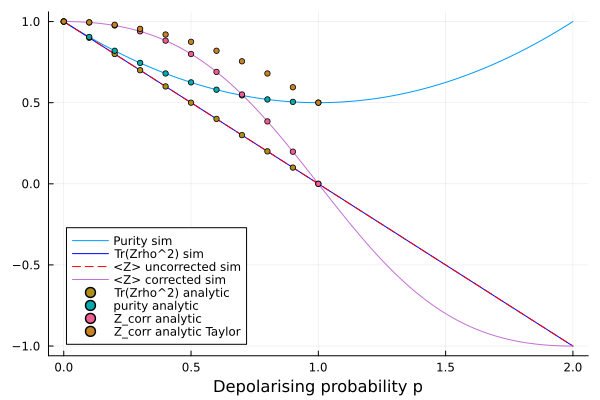

In [57]:
psi_0 = tensor(up, up)
p_list = collect(0:1e-3:2.)
purity_list = []
corrected_list = []
uncorrected_list = []
tr_rho_2_Z_list = []

for p in p_list
    # Create initial state
    psi = Rn_id(psi_0, 0, sx, 0)
    psi = Rn_id(psi, 0, sx, 1)

    rho = depol_chan(psi, p)

    # Apply B matrix circuit
    rho_derang = B_matrix_dm(rho)

    # Measure the state in the computational basis
    p_uu, p_dd, p_ud, p_du = measure2_dm(rho_derang)

    # Post process
    M0 = p_uu + p_ud - p_du - p_dd
    M1 = p_uu + p_du - p_ud - p_dd
    M01 = p_uu+ p_dd - p_ud - p_du
    purity = 1/2 * ( 1 + M0 - M1 + M01)
    tr_rho_2_Z = 1/2 * (M0 + M1)
    push!(purity_list, purity)
    push!(tr_rho_2_Z_list, tr_rho_2_Z)
    push!(corrected_list, tr_rho_2_Z/purity)

    # measure without correction
    rho_red = ptrace(rho, [1])
    p_up = real(expect(projector(up), rho_red))
    p_down = real(expect(projector(down), rho_red))
    M0_uncorrected = p_up - p_down
    push!(uncorrected_list, M0_uncorrected)
end
plot(p_list, purity_list, label="Purity sim", xlabel="Depolarising probability p")
plot!(p_list, tr_rho_2_Z_list, label="Tr(Zrho^2) sim", linestyle=:solid, color=:blue)
plot!(p_list, uncorrected_list, label="<Z> uncorrected sim", linestyle=:dash, xlabel="Depolarising probability p",color=:red)
plot!(p_list, corrected_list, label="<Z> corrected sim", linestyle=:solid)

fit_list = collect(0:1e-1:1.) 
Tr_fit_list = (-fit_list.*1 .+1) 
plot!(fit_list, Tr_fit_list, label="Tr(Zrho^2) analytic", markershape=:circle, markersize=3, seriestype=:scatter)
fid_fit_list = (-fit_list .+fit_list.^(2)/2  .+1) 
plot!(fit_list, fid_fit_list, label="purity analytic", markershape=:circle, markersize=3, seriestype=:scatter)
Z_corr_fit_list =  Tr_fit_list ./ fid_fit_list
plot!(fit_list, Z_corr_fit_list, label="Z_corr analytic", markershape=:circle, markersize=3, seriestype=:scatter)

taylor_fit_list = ( -fit_list.^2 ./2 .+ 1)
plot!(fit_list, taylor_fit_list, label="Z_corr analytic Taylor", markershape=:circle, markersize=3, seriestype=:scatter)
# save plot as png
#savefig("b_matrix_results.png")


